# Governed process-to-engineering package and CFIHOS handover

<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/governed_process_to_engineering_handover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This tutorial turns a live NeqSim process model into a governed, review-required engineering package. It executes three controlled operating cases, closes the native engineering design loop, compiles coordinated DEXPI and discipline deliverables, checks numerical health, and stages a CFIHOS 2.0 handover with an explicit gap register.

The released Python distribution is used only as the JPype bridge. Java calculations use the JAR built from current `equinor/neqsim` `master`; the exact commit, JAR SHA-256, and loaded class location are retained in the first output.

Learning outcomes:

- keep the source process immutable while sizing an isolated engineering copy;
- trace every selected design variable to its governing case and calculation evidence;
- compile mutually consistent registers, datasheets, diagrams, and exchange files;
- distinguish numerical validity, DEXPI conformance, and contractual handover approval; and
- package machine-readable artifacts with executable validation evidence.


In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import importlib.util
import os
import platform
import subprocess
import sys

PYTHON_NEQSIM_VERSION = "3.16.0"
NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")

try:
    installed_bridge_version = version("neqsim")
except PackageNotFoundError:
    installed_bridge_version = None
if installed_bridge_version != PYTHON_NEQSIM_VERSION:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            f"neqsim=={PYTHON_NEQSIM_VERSION}",
        ],
        check=True,
    )

using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ
if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

# Record the immutable commit selected from current master (git rev-parse HEAD).
NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master source build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(jar_candidates, key=lambda path: len(path.name))[0]

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import jpype

if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the NeqSim master JAR was selected. "
        "Restart the runtime and run all cells."
    )
jpype.addClassPath(str(SOURCE_JAR))
from neqsim.neqsimpython import init_jvm

init_jvm()
SOURCE_PROBE = jpype.JClass(
    "neqsim.process.engineering.design.EngineeringDesignLoop"
)
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION

neqsim_version = version("neqsim")
print(f"NeqSim Python bridge: {neqsim_version}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Loaded Java classes from: {LOADED_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")

import json
import math
import shutil
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import FileLink, display

JClass = jpype.JClass
JProxy = jpype.JProxy
plt.style.use("seaborn-v0_8-whitegrid")
print("Loaded main-only process-to-engineering classes from", LOADED_JAR_LOCATION)


NeqSim Python bridge: 3.16.0
NeqSim source ref: master
NeqSim source commit: 13a6f31ee4ce3d5394291edc2179ffb6993eb130
NeqSim source JAR SHA-256: ee992a648f93835feca4bfb4a2b6cb0f356afe4f89282259b3b4048f32310da3
Loaded Java classes from: file:/workspace/scratch/ab308ea4a4a5/neqsim-main-build/target/neqsim-3.16.0.jar
Python runtime: 3.12.13
Loaded main-only process-to-engineering classes from file:/workspace/scratch/ab308ea4a4a5/neqsim-main-build/target/neqsim-3.16.0.jar


## 1. Controlled process model and design basis

The base process intentionally starts with preliminary geometry. The engineering simulator copies this process before applying selected sizes, so the source model remains an auditable calculation basis. Absolute pressure is used throughout.

The process boundary closes from feed through separation, compression, and export hydraulics. For each design case, the simulator evaluates the coupled process response before accepting an update.


In [2]:
SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
Stream = JClass("neqsim.process.equipment.stream.Stream")
Separator = JClass("neqsim.process.equipment.separator.Separator")
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")
AdiabaticPipe = JClass("neqsim.process.equipment.pipeline.AdiabaticPipe")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")

fluid = SystemSrkEos(300.0, 50.0)
for component, amount in [
    ("methane", 0.92),
    ("ethane", 0.04),
    ("n-heptane", 0.04),
]:
    fluid.addComponent(component, amount)
fluid.setMixingRule("classic")

feed = Stream("FEED", fluid)
feed.setFlowRate(8000.0, "kg/hr")
separator = Separator("INLET-SEP", feed)
compressor = Compressor("EXPORT-COMP", separator.getGasOutStream())
compressor.setOutletPressure(80.0, "bara")
compressor.setPolytropicEfficiency(0.78)
export_line = AdiabaticPipe("EXPORT-LINE", compressor.getOutletStream())
export_line.setLength(1000.0)
export_line.setDiameter(0.2027)
export_line.setPipeWallRoughness(4.6e-5)

process = ProcessSystem()
for unit in [feed, separator, compressor, export_line]:
    process.add(unit)
process.run()

base_line_diameter = export_line.getDiameter()
base_mass_flow_kg_h = feed.getFlowRate("kg/hr")
print(f"Base process solved at {base_mass_flow_kg_h:.1f} kg/h")
print(f"Preliminary export-line internal diameter: {base_line_diameter:.4f} m")


Base process solved at 8000.0 kg/h
Preliminary export-line internal diameter: 0.2027 m


## 2. Controlled cases and native engineering modules

Three traceable flow cases define the design envelope. The callbacks change only case inputs on isolated process copies. Each design result retains the governing case and the case-set fingerprint.


In [3]:
NorsokBuilder = JClass(
    "neqsim.process.engineering.NorsokOffshoreEngineeringBuilder"
)
DesignBuilder = JClass(
    "neqsim.process.engineering.ProcessToEngineeringDesignBuilder"
)
DesignCase = JClass(
    "neqsim.process.engineering.designcase.EngineeringDesignCase"
)
DesignCaseInput = JClass(
    "neqsim.process.engineering.designcase.EngineeringDesignCase$Input"
)
Configurator = JClass(
    "neqsim.process.engineering.designcase.EngineeringDesignCase$Configurator"
)

project = (
    NorsokBuilder.from_("Notebook process-to-engineering design", process)
    .projectId("pte-notebook")
    .build()
)

def add_flow_case(case_id, flow_kg_h, priority):
    def configure(case_process):
        case_process.getUnit("FEED").setFlowRate(flow_kg_h, "kg/hr")

    proxy = JProxy(Configurator, dict={"configure": configure})
    design_case = DesignCase(
        case_id,
        case_id,
        DesignCase.Type.CUSTOM,
        proxy,
    ).setPriority(priority)
    design_case.addInput(
        DesignCaseInput(
            "feedFlow",
            flow_kg_h,
            "kg/hr",
            "NOTEBOOK-DESIGN-BASIS",
        )
    )
    project.addDesignCase(design_case)

add_flow_case("turndown", 5000.0, 5)
add_flow_case("normal", 8000.0, 10)
add_flow_case("maximum", 12000.0, 20)

driver_ratings_kw = jpype.JArray(jpype.JDouble)(
    [500, 1000, 2000, 3000, 5000, 7500, 10000]
)
builder = (
    DesignBuilder.on(project)
    .exportLineLimits(25.0, 5.0)
    .compressorDrivers(0.10, driver_ratings_kw)
)
builder.addInletCompressionExportSlice(
    "INLET-SEP",
    "EXPORT-COMP",
    "EXPORT-LINE",
    "",
    "PIT-100",
)
print("Controlled cases:", project.getExecutableDesignCases().size())
print("Engineering modules:", project.getEngineeringDesignModules().size())


Controlled cases: 3
Engineering modules: 7


## 3. Close the process-to-engineering design loop

A converged result means both selected physical variables and the resulting process values stabilized for the declared cases. It is not construction approval. For iteration $k$, this notebook monitors

$$
\epsilon_x^{(k)} = \max_i \left|\frac{x_i^{(k)}-x_i^{(k-1)}}{\max(|x_i^{(k-1)}|, x_{i,\mathrm{floor}})}\right|
$$

and an equivalent process-value metric $\epsilon_p^{(k)}$. The loop accepts convergence only after updates and both metrics satisfy the governed rules.


In [4]:
Simulator = JClass(
    "neqsim.process.engineering.ProcessToEngineeringSimulator"
)
result = Simulator.run(project, 3)
loop = result.getEngineeringDesignLoopResult()

design_rows = []
for entry in loop.getState().getValues().entrySet():
    value = entry.getValue()
    design_rows.append(
        {
            "design variable": str(entry.getKey()),
            "value": float(value.getValue()),
            "unit": str(value.getUnit()),
        }
    )
design_table = (
    pd.DataFrame(design_rows)
    .sort_values("design variable")
    .reset_index(drop=True)
)
print("Converged:", loop.isConverged())
print("Iterations:", loop.getIterations().size())
display(design_table)

assert loop.isConverged()
assert design_table["value"].map(math.isfinite).all()
assert abs(process.getUnit("EXPORT-LINE").getDiameter() - base_line_diameter) < 1.0e-12
assert abs(process.getUnit("FEED").getFlowRate("kg/hr") - base_mass_flow_kg_h) < 1.0e-9


Converged: True
Iterations: 3


,design variable,value,unit
0,EXPORT-COMP.driverRatedPower,500.000000,kW
1,EXPORT-COMP.driverUtilization,0.361689,fraction
2,EXPORT-COMP.maximumActualInletFlow,0.072086,m3/s
3,EXPORT-LINE.designVelocity,1.584175,m/s
4,EXPORT-LINE.insideDiameter,0.202700,m
5,EXPORT-LINE.predictedPressureGradient,0.048304,bar/km
6,INLET-SEP.blowdownTargetPressure,6.900000,bara
7,INLET-SEP.corrosionAllowance,3.000000,mm
8,INLET-SEP.designLife,25.000000,year
9,INLET-SEP.designPressure,55.000000,bara


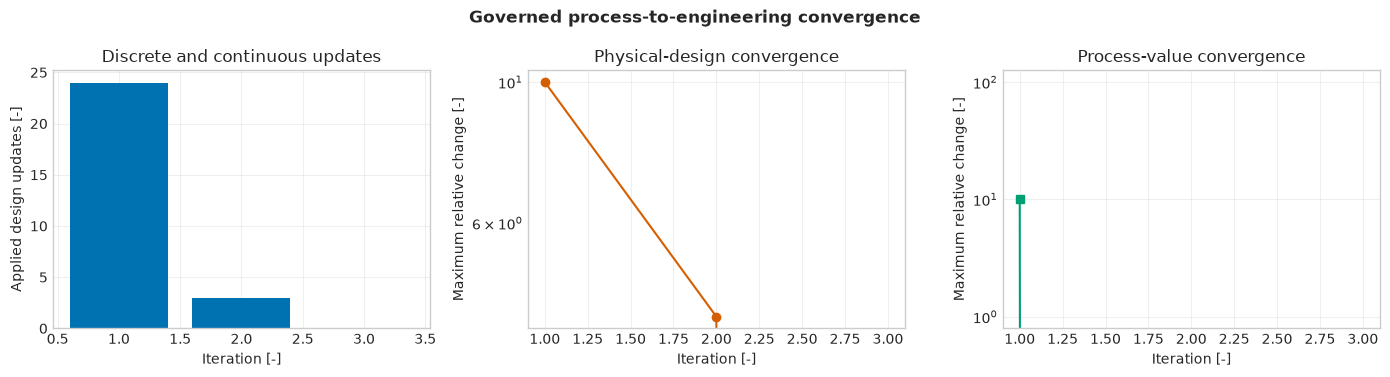

In [5]:
iteration_numbers = [
    item.getNumber() for item in loop.getIterations()
]
applied_updates = [
    item.getAppliedUpdateCount() for item in loop.getIterations()
]
physical_changes = [
    min(item.getMaximumRelativeChange(), 10.0)
    for item in loop.getIterations()
]
process_changes = [
    min(
        item.getConvergenceReport().getMaximumProcessValueRelativeChange(),
        10.0,
    )
    for item in loop.getIterations()
]

figure, axes = plt.subplots(1, 3, figsize=(14.0, 3.8))
axes[0].bar(iteration_numbers, applied_updates, color="#0072B2")
axes[0].set(
    xlabel="Iteration [-]",
    ylabel="Applied design updates [-]",
    title="Discrete and continuous updates",
)
axes[1].semilogy(
    iteration_numbers,
    physical_changes,
    marker="o",
    color="#D55E00",
)
axes[1].set(
    xlabel="Iteration [-]",
    ylabel="Maximum relative change [-]",
    title="Physical-design convergence",
)
axes[2].semilogy(
    iteration_numbers,
    process_changes,
    marker="s",
    color="#009E73",
)
axes[2].set(
    xlabel="Iteration [-]",
    ylabel="Maximum relative change [-]",
    title="Process-value convergence",
)
for axis in axes:
    axis.grid(True, alpha=0.3)
figure.suptitle("Governed process-to-engineering convergence", fontweight="bold")
figure.tight_layout()
plt.show()


The first iteration applies continuous calculations and discrete candidates. A following hydraulic pass measures the connected process response, and the final iteration proves that both physical design variables and process values are stable. Initial infinite changes are clipped at 10 only for logarithmic plotting; the native convergence decision is unchanged.


## 4. Compile a coordinated engineering package

The compiler uses the designed process copy, the complete case envelope, canonical engineering graph identities, and calculation evidence. The output includes DEXPI exchange, discipline registers, datasheets, diagrams, calculation evidence, and unresolved actions.


In [6]:
Compiler = JClass(
    "neqsim.process.engineering.deliverables.EngineeringDeliverableCompiler"
)
Paths = JClass("java.nio.file.Paths")

default_artifact_root = (
    Path("/content/neqsim-governed-engineering-package")
    if Path("/content").is_dir()
    else Path("/tmp/neqsim-governed-engineering-package")
)
package_dir = Path(
    os.environ.get("NEQSIM_ARTIFACT_ROOT", str(default_artifact_root))
).resolve()
if package_dir.exists():
    raise FileExistsError(
        f"Artifact directory already exists: {package_dir}. "
        "Use a new NEQSIM_ARTIFACT_ROOT for a clean run."
    )

compiled = Compiler.compile(project, Paths.get(str(package_dir)))
top_level_artifacts = sorted(path.name for path in package_dir.iterdir())
print("Package valid:", compiled.getValidationReport().isValid())
print("DEXPI 2.0:", compiled.getDexpiResult().getDexpi20File())
print("Generated top-level artifacts:", len(top_level_artifacts))

required_artifacts = [
    "plant.dexpi.xml",
    "engineering-calculations.json",
    "engineering-diagram-layout.json",
    "equipment-datasheets.json",
    "io-list.json",
    "alarm-trip-schedule.json",
    "psv-datasheets.json",
    "utility-summary.json",
    "materials-selection-report.json",
    "unresolved-engineering-actions.json",
]
assert compiled.getValidationReport().isValid()
for artifact_name in required_artifacts:
    assert (package_dir / artifact_name).exists(), artifact_name


Package valid: True
DEXPI 2.0: /tmp/neqsim-pr2-artifacts-run3/plant.dexpi.xml
Generated top-level artifacts: 48


The package remains review-required. HAZOP/LOPA, SIL approval, vendor guarantees, final code design, materials approval, cybersecurity review, construction authorization, and the Principal's information acceptance remain accountable engineering activities.


## 5. Numerical health and native DEXPI 2.0 Process exchange

The numerical-health analyzer checks the governed process rather than assuming a converged solver is automatically suitable for design. The native Process exporter then assesses the official Core-plus-Process schema/profile used for PFD/BFD exchange. Named CAE round-trip qualification remains a project responsibility.


In [7]:
NumericalHealthAnalyzer = JClass(
    "neqsim.process.engineering.numerics.EngineeringNumericalHealthAnalyzer"
)
DexpiProcessWriter = JClass(
    "neqsim.process.processmodel.dexpi.Dexpi20ProcessModelWriter"
)
JavaFile = JClass("java.io.File")

numerical_health = NumericalHealthAnalyzer.analyze(
    project.getEngineeringProcessSystem()
)
process_exchange = package_dir / "process-model.dexpi.xml"
process_conformance = DexpiProcessWriter.writeAndAssess(
    project.getEngineeringProcessSystem(),
    JavaFile(str(process_exchange)),
)
print("Numerical health:", numerical_health.getStatus().name())
print(
    "Native Process profile conformant:",
    process_conformance.isSchemaAndProfileConformant(),
)
print(
    "Named CAE status:",
    process_conformance.toMap().get("namedCaeRoundTripStatus"),
)
assert numerical_health.getStatus().name() != "FAILED"
assert process_conformance.isSchemaAndProfileConformant()
assert (package_dir / "engineering-numerical-health.json").exists()


Numerical health: HEALTHY
Native Process profile conformant: True
Named CAE status: QUALIFICATION_REQUIRED


## 6. Stage a controlled CFIHOS 2.0 handover

Handover completeness is a separate gate from process and package validity. Define

$$
C_{\mathrm{handover}} = 1 - \frac{N_{\mathrm{open\ gaps}}}{\max(N_{\mathrm{required\ mappings}}, 1)}.
$$

This tutorial deliberately uses `EXAMPLE-*` identifiers and withholds project mapping approval. The exporter writes deterministic tags, equipment, properties, documents, relationships, a manifest, and a gap register, but must report `INCOMPLETE`. Replace every example identifier with controlled Core or Extended RDL identifiers and record accountable approval before project handover.


In [8]:
CfihosMapping = JClass(
    "neqsim.process.engineering.handover.Cfihos20ReferenceDataMapping"
)
CfihosEdition = JClass(
    "neqsim.process.engineering.handover.Cfihos20ReferenceDataMapping$Edition"
)
CfihosExporter = JClass(
    "neqsim.process.engineering.handover.Cfihos20HandoverExporter"
)

example_rdl = package_dir / "notebook-example-cfihos-rdl.txt"
example_rdl.write_text(
    "Notebook-only example mapping; not an official CFIHOS RDL delivery.\n",
    encoding="utf-8",
)
mapping_builder = (
    CfihosMapping.builder(CfihosEdition.CORE)
    .verifiedSource(
        "urn:neqsim:notebook:example-rdl",
        Paths.get(str(example_rdl)),
    )
)
for node in compiled.getEngineeringGraph().getNodes().values():
    node_kind = str(node.getKind().name())
    if node_kind in ("EQUIPMENT", "LINE", "INSTRUMENT", "BOUNDARY"):
        equipment_class = (
            "EXAMPLE-EQUIPMENT-CLASS"
            if node_kind == "EQUIPMENT"
            else None
        )
        mapping_builder.mapNode(
            node.getId(),
            "EXAMPLE-TAG-CLASS-" + node_kind,
            equipment_class,
        )
    elif node_kind == "DOCUMENT":
        mapping_builder.mapDocument(
            node.getExternalKey(),
            "EXAMPLE-DOCUMENT-TYPE",
        )

cfihos_mapping = mapping_builder.build()
cfihos_dir = package_dir / "cfihos-20-staging"
assert not cfihos_dir.exists()
cfihos = CfihosExporter.export(
    compiled.getEngineeringGraph(),
    cfihos_mapping,
    Paths.get(str(cfihos_dir)),
)
print("CFIHOS staging status:", cfihos.getReport().getStatus().name())
print("Manifest:", cfihos.getManifestFile())
print("Gap register:", cfihos.getUnmappedFile())
assert cfihos.getReport().getStatus().name() == "INCOMPLETE"
assert (cfihos_dir / "cfihos-20-manifest.json").exists()
assert (cfihos_dir / "cfihos-tags.csv").exists()
assert (cfihos_dir / "cfihos-unmapped.csv").exists()


CFIHOS staging status: INCOMPLETE
Manifest: /tmp/neqsim-pr2-artifacts-run3/cfihos-20-staging/cfihos-20-manifest.json
Gap register: /tmp/neqsim-pr2-artifacts-run3/cfihos-20-staging/cfihos-unmapped.csv


The staging CSVs are a NeqSim-neutral profile, not a Principal bulk-loader template or a CFIHOS conformance certificate. The Principal remains responsible for contractual data requirements, approved mappings, target-system transformation, validation, load receipts, and final information acceptance.


## 7. Evidence dashboard, validation summary, and downloadable package

The notebook closes with named assertions rather than a visual success claim. The mass-flow design envelope is explicit:

$$
\dot m_{\mathrm{turndown}} \le \dot m_{\mathrm{normal}} \le \dot m_{\mathrm{maximum}},
$$

The source process must remain at its original normal-case rate and preliminary diameter. The CFIHOS gate remains open by design, so `INCOMPLETE` is a successful fail-closed outcome here.


Total generated files: 87
Open CFIHOS mapping gaps: 70


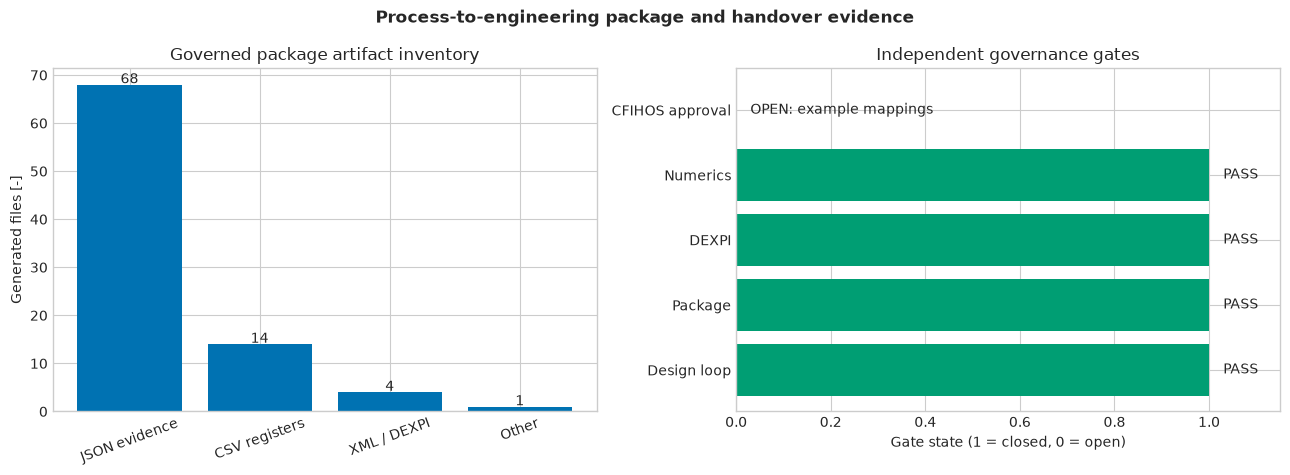

,check,passed
0,main-source class location,True
1,three controlled cases,True
2,native design loop converged,True
3,finite selected variables,True
4,source process diameter unchanged,True
5,source process flow unchanged,True
6,compiled package valid,True
7,native DEXPI Process conformant,True
8,numerical health not failed,True
9,CFIHOS gaps fail closed,True


,relative path,bytes
0,alarm-trip-schedule.json,3477
1,cause-and-effect.json,6315
2,cfihos-20-staging/cfihos-20-assessment.json,26621
3,cfihos-20-staging/cfihos-20-manifest.json,5191
4,cfihos-20-staging/cfihos-documents.csv,6637
5,cfihos-20-staging/cfihos-equipment.csv,410
6,cfihos-20-staging/cfihos-properties.csv,64
7,cfihos-20-staging/cfihos-relationships.csv,401
8,cfihos-20-staging/cfihos-tags.csv,504
9,cfihos-20-staging/cfihos-unmapped.csv,11309


In [9]:
cfihos_gaps = pd.read_csv(cfihos_dir / "cfihos-unmapped.csv")
all_artifacts = sorted(
    path for path in package_dir.rglob("*") if path.is_file()
)

def artifact_category(path):
    suffix = path.suffix.lower()
    if suffix == ".json":
        return "JSON evidence"
    if suffix == ".csv":
        return "CSV registers"
    if suffix in (".xml", ".dexpi") or path.name.endswith(".dexpi.xml"):
        return "XML / DEXPI"
    return "Other"

artifact_counts = Counter(
    artifact_category(path) for path in all_artifacts
)
validation_checks = {
    "main-source class location": SOURCE_JAR.name in LOADED_JAR_LOCATION,
    "three controlled cases": project.getExecutableDesignCases().size() == 3,
    "native design loop converged": loop.isConverged(),
    "finite selected variables": design_table["value"].map(math.isfinite).all(),
    "source process diameter unchanged": abs(
        process.getUnit("EXPORT-LINE").getDiameter() - base_line_diameter
    ) < 1.0e-12,
    "source process flow unchanged": abs(
        process.getUnit("FEED").getFlowRate("kg/hr") - base_mass_flow_kg_h
    ) < 1.0e-9,
    "compiled package valid": compiled.getValidationReport().isValid(),
    "native DEXPI Process conformant": (
        process_conformance.isSchemaAndProfileConformant()
    ),
    "numerical health not failed": (
        numerical_health.getStatus().name() != "FAILED"
    ),
    "CFIHOS gaps fail closed": (
        cfihos.getReport().getStatus().name() == "INCOMPLETE"
        and len(cfihos_gaps) > 0
    ),
    "required artifacts present": all(
        (package_dir / name).exists() for name in required_artifacts
    ),
}
# Normalize JPype and NumPy boolean wrappers before JSON serialization.
validation_checks = {
    name: True if value else False
    for name, value in validation_checks.items()
}
assert all(validation_checks.values()), validation_checks

figure, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
category_order = [
    "JSON evidence",
    "CSV registers",
    "XML / DEXPI",
    "Other",
]
category_values = [
    artifact_counts.get(name, 0) for name in category_order
]
axes[0].bar(category_order, category_values, color="#0072B2")
axes[0].set(
    ylabel="Generated files [-]",
    title="Governed package artifact inventory",
)
axes[0].tick_params(axis="x", rotation=20)
for index, value in enumerate(category_values):
    axes[0].text(index, value + 0.3, str(value), ha="center")

gate_names = [
    "Design loop",
    "Package",
    "DEXPI",
    "Numerics",
    "CFIHOS approval",
]
gate_values = [1, 1, 1, 1, 0]
gate_colors = ["#009E73"] * 4 + ["#D55E00"]
axes[1].barh(gate_names, gate_values, color=gate_colors)
axes[1].set(
    xlabel="Gate state (1 = closed, 0 = open)",
    xlim=(0.0, 1.15),
    title="Independent governance gates",
)
for index, value in enumerate(gate_values):
    label = "PASS" if value else "OPEN: example mappings"
    axes[1].text(value + 0.03, index, label, va="center")
figure.suptitle(
    "Process-to-engineering package and handover evidence",
    fontweight="bold",
)
figure.tight_layout()
plt.show()

check_table = pd.DataFrame(
    {
        "check": list(validation_checks),
        "passed": list(validation_checks.values()),
    }
)
artifact_table = pd.DataFrame(
    {
        "relative path": [
            str(path.relative_to(package_dir)) for path in all_artifacts
        ],
        "bytes": [path.stat().st_size for path in all_artifacts],
    }
)
display(check_table)
display(artifact_table.head(25))
print("Total generated files:", len(all_artifacts))
print("Open CFIHOS mapping gaps:", len(cfihos_gaps))


In [10]:
validation_summary = {
    "schema": "neqsim.colab.governed-engineering-package.v1",
    "neqsim_source": {
        "repository": NEQSIM_SOURCE_REPOSITORY,
        "requested_ref": NEQSIM_SOURCE_REF,
        "resolved_commit": NEQSIM_SOURCE_COMMIT,
        "jar_sha256": SOURCE_JAR_SHA256,
        "loaded_from": LOADED_JAR_LOCATION,
    },
    "controlled_cases": int(project.getExecutableDesignCases().size()),
    "engineering_modules": int(project.getEngineeringDesignModules().size()),
    "design_iterations": int(loop.getIterations().size()),
    "package_valid": True if compiled.getValidationReport().isValid() else False,
    "numerical_health": str(numerical_health.getStatus().name()),
    "dexpi_process_conformant": (
        True if process_conformance.isSchemaAndProfileConformant() else False
    ),
    "cfihos_status": str(cfihos.getReport().getStatus().name()),
    "cfihos_open_gaps": int(len(cfihos_gaps)),
    "generated_files_before_summary": int(len(all_artifacts)),
    "checks": validation_checks,
}
summary_path = package_dir / "notebook-validation-summary.json"
summary_path.write_text(
    json.dumps(validation_summary, indent=2) + "\n",
    encoding="utf-8",
)
archive_base = package_dir.parent / package_dir.name
archive_path = Path(
    shutil.make_archive(
        str(archive_base),
        "zip",
        root_dir=package_dir,
    )
)
print(json.dumps(validation_summary, indent=2))
print(f"Archive size: {archive_path.stat().st_size / 1024.0:.1f} KiB")
display(FileLink(str(archive_path)))


{
  "schema": "neqsim.colab.governed-engineering-package.v1",
  "neqsim_source": {
    "repository": "https://github.com/equinor/neqsim.git",
    "requested_ref": "master",
    "resolved_commit": "13a6f31ee4ce3d5394291edc2179ffb6993eb130",
    "jar_sha256": "ee992a648f93835feca4bfb4a2b6cb0f356afe4f89282259b3b4048f32310da3",
    "loaded_from": "file:/workspace/scratch/ab308ea4a4a5/neqsim-main-build/target/neqsim-3.16.0.jar"
  },
  "controlled_cases": 3,
  "engineering_modules": 7,
  "design_iterations": 3,
  "package_valid": true,
  "numerical_health": "HEALTHY",
  "dexpi_process_conformant": true,
  "cfihos_status": "INCOMPLETE",
  "cfihos_open_gaps": 70,
  "generated_files_before_summary": 87,
  "checks": {
    "main-source class location": true,
    "three controlled cases": true,
    "native design loop converged": true,
    "finite selected variables": true,
    "source process diameter unchanged": true,
    "source process flow unchanged": true,
    "compiled package valid": true,

/tmp/neqsim-pr2-artifacts-run3.zip

## 8. Interpretation, limitations, and exercises

The case envelope governs different decisions through one traceable graph: maximum flow normally governs compressor and export-line capacity, while the compiler propagates selected values into connected discipline artifacts. Numerical health and DEXPI schema/profile checks pass independently. CFIHOS remains `INCOMPLETE` because example identifiers are deliberately not contractual reference-data mappings; this is evidence that the handover interface fails closed.

Limitations:

- this is preliminary educational design, not detailed design or construction authorization;
- the three flow cases do not replace a project-approved operating and accidental case register;
- the simple SRK fluid and compact process omit water, acid-gas, hydrate, wax, corrosion, relief-dispersion, and dynamic-control studies;
- DEXPI schema/profile conformance does not prove named CAE round-trip fidelity; and
- CFIHOS acceptance requires the Principal's controlled RDL, contractual data requirements, mappings, transformations, validation, and load receipts.

Exercises:

1. Add high-temperature, low-suction-pressure, and composition cases and identify which case governs each design variable.
2. Replace the example CFIHOS mappings with an approved project mapping file and demonstrate a closed handover gate.
3. Add a second compression stage and verify that datasheets, I/O, utilities, and DEXPI remain mutually consistent.
4. Compare the native export-line selection with an independent hydraulic calculation and document the model-form uncertainty.
